# Importing Data 

- Plant
- Generation
- Weather

In [1]:
import pandas as pd

plant = pd.read_csv(r"D:\Portfolio Github\Pravaah\data\plant_master.csv")
weather = pd.read_csv(r"D:\Portfolio Github\Pravaah\data\weather_data.csv", parse_dates=["timestamp"])
generation = pd.read_csv(r"D:\Portfolio Github\Pravaah\data\generation.csv", parse_dates=["timestamp"])


# Merge plant with generation on 'plant_id'
merged_df = plant.merge(generation, on=['plant_id', 'plant_type' ,'region'], how='left')

# Merge with weather on 'plant_id' and 'timestamp'
merged_df = merged_df.merge(weather, on=['plant_name', 'timestamp'], how='left')

final_df = merged_df.drop(columns=[ 'plant_name',
    'latitude', 'longitude', 'commission_date', 'region', 'state',
    'developer', 'offtaker', 'status'
])

final_df.columns

Index(['plant_id', 'plant_type', 'capacity_mw', 'timestamp',
       'actual_generation_mw', 'availability_mw', 'curtailment_mw',
       'health_factor', 'irradiance_wm2', 'temperature', 'cloud_cover',
       'wind_speed', 'wind_direction', 'irradiance'],
      dtype='str')

# Pre-processing

**Input columns (from your merged dataframe):**
plant_id, plant_type, 
capacity_mw, actual_generation_mw, availability_mw, curtailment_mw, 
health_factor, irradiance_wm2,
temperature, cloud_cover, wind_speed, wind_direction,irradiance

**Steps:**
- 1. Schema validation      — check required columns exist, right dtypes
- 2. Duplicate column fix   — irradiance vs irradiance_wm2
- 3. Physical bounds check  — clip impossible sensor values
- 4. Missing value strategy — per-column imputation logic
- 5. Outlier treatment      — IQR + domain-aware capping
- 6. Categorical encoding   — plant_type → integer codes + dummies
- 7. Derived base columns   — things FE pipeline expects but aren't in raw data
- 8. Per-plant normalisation — optional, for cross-plant ML
- 9. Final dtype cast       — everything to float32 except IDs
- 10. QA report              — summary of what was changed

In [2]:
from src.preprocessing import preprocess

df_clean = preprocess(final_df)


────────────────────────────────────────────────────────────
  STARTING PRE-PROCESSING PIPELINE
────────────────────────────────────────────────────────────
[OK] Schema validated — 574,850 rows, 14 columns
[INFO] irradiance_wm2 vs irradiance correlation: 0.6111
[OK] Merged irradiance_wm2 + irradiance → single 'irradiance' column
[OK] Numeric dtypes enforced
[OK] Imputation complete — nulls reduced: 919,760 → 229,940
[WARN] Remaining nulls:
temperature    229940
dtype: int64
[OK] Outlier treatment done (iqr) on: ['actual_generation_mw', 'availability_mw', 'temperature', 'cloud_cover', 'wind_speed', 'irradiance']
[OK] Encoded plant_type → codes + dummies: ['plant_type_Hybrid', 'plant_type_Solar', 'plant_type_Wind']
[OK] Aliased actual_generation_mw → generation
[OK] Derived base columns added
[OK] Per-plant normalisation: capacity
[OK] Dtypes optimised — memory usage: 62.0 MB

════════════════════════════════════════════════════════════
  PRE-PROCESSING QA REPORT
═══════════════════════

# Categorize the data

In [3]:
df_solar = df_clean[df_clean['plant_type'] == 'Solar'].copy()
df_wind = df_clean[df_clean['plant_type'] == 'Wind'].copy()
df_hybrid = df_clean[df_clean['plant_type'] == 'Hybrid'].copy()    

# Feature Engineering

## Derived Features

In [4]:

from src.features import build_features

df_solar = build_features(df_solar, "Solar")
df_wind = build_features(df_wind, "Wind")
df_hybrid = build_features(df_hybrid, "Hybrid")

df_solar.drop(columns=['plant_type'], inplace=True)
df_wind.drop(columns=['plant_type'], inplace=True)
df_hybrid.drop(columns=['plant_type'], inplace=True)

In [5]:
df_solar.columns

Index(['plant_id', 'capacity_mw', 'timestamp', 'actual_generation_mw',
       'availability_mw', 'curtailment_mw', 'health_factor', 'temperature',
       'cloud_cover', 'wind_speed', 'wind_direction', 'irradiance',
       'plant_type_code', 'plant_type_Hybrid', 'plant_type_Solar',
       'plant_type_Wind', 'generation', 'capacity_factor',
       'generation_shortfall_mw', 'net_availability_mw',
       'health_adjusted_capacity_mw', 'is_degraded', 'is_offline',
       'generation_norm', 'hour', 'day_of_year', 'month', 'day_of_week',
       'is_weekend', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin',
       'month_cos', 'clear_sky_irradiance', 'irradiance_adjusted',
       'irradiance_ratio', 'temp_effect', 'expected_generation',
       'performance_ratio', 'pr_rolling_7', 'pr_rolling_30',
       'days_since_cleaning', 'soiling_loss', 'adjusted_generation_signal',
       'is_daylight', 'gen_lag_1', 'gen_lag_24', 'gen_lag_168',
       'gen_rolling_mean_6', 'gen_rolling_std_6',

In [6]:
df_wind.columns

Index(['plant_id', 'capacity_mw', 'timestamp', 'actual_generation_mw',
       'availability_mw', 'curtailment_mw', 'health_factor', 'temperature',
       'cloud_cover', 'wind_speed', 'wind_direction', 'irradiance',
       'plant_type_code', 'plant_type_Hybrid', 'plant_type_Solar',
       'plant_type_Wind', 'generation', 'capacity_factor',
       'generation_shortfall_mw', 'net_availability_mw',
       'health_adjusted_capacity_mw', 'is_degraded', 'is_offline',
       'generation_norm', 'hour', 'day_of_year', 'month', 'day_of_week',
       'is_weekend', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin',
       'month_cos', 'wind_speed_squared', 'wind_speed_cubed',
       'wind_power_density', 'turbine_efficiency', 'expected_wind_generation',
       'wind_dir_sin', 'wind_dir_cos', 'air_density_adjusted', 'adjusted_wpd',
       'is_below_cut_in', 'is_above_cut_out', 'wind_speed_diff',
       'wind_speed_rolling_std_6', 'gen_lag_1', 'gen_lag_24', 'gen_lag_168',
       'gen_rolling_

In [7]:
df_hybrid.columns

Index(['plant_id', 'capacity_mw', 'timestamp', 'actual_generation_mw',
       'availability_mw', 'curtailment_mw', 'health_factor', 'temperature',
       'cloud_cover', 'wind_speed', 'wind_direction', 'irradiance',
       'plant_type_code', 'plant_type_Hybrid', 'plant_type_Solar',
       'plant_type_Wind', 'generation', 'capacity_factor',
       'generation_shortfall_mw', 'net_availability_mw',
       'health_adjusted_capacity_mw', 'is_degraded', 'is_offline',
       'generation_norm', 'hour', 'day_of_year', 'month', 'day_of_week',
       'is_weekend', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin',
       'month_cos', 'clear_sky_irradiance', 'irradiance_adjusted',
       'irradiance_ratio', 'temp_effect', 'expected_generation',
       'performance_ratio', 'pr_rolling_7', 'pr_rolling_30',
       'days_since_cleaning', 'soiling_loss', 'adjusted_generation_signal',
       'is_daylight', 'wind_speed_squared', 'wind_speed_cubed',
       'wind_power_density', 'turbine_efficiency'

## Feature Selection

### Step 1 — Correlation filter (multicollinearity)

In [8]:
import numpy as np

def drop_correlated_features(df, threshold=0.90, exclude=["timestamp","plant_id","plant_type","generation"]):
    numeric = df.drop(columns=exclude, errors="ignore").select_dtypes("number")
    corr = numeric.corr().abs()
    
    # Upper triangle only — avoid double-dropping
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    print(f"Dropping {len(to_drop)} correlated features: {to_drop}")
    return df.drop(columns=to_drop)

In [9]:
!pip install --quiet seaborn
!pip install matplotlib --quiet


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Processing Solar dataframe
Dropping 22 correlated features: ['availability_mw', 'capacity_factor', 'generation_shortfall_mw', 'net_availability_mw', 'health_adjusted_capacity_mw', 'generation_norm', 'month', 'month_sin', 'month_cos', 'clear_sky_irradiance', 'irradiance_ratio', 'temp_effect', 'soiling_loss', 'adjusted_generation_signal', 'gen_rolling_mean_6', 'gen_rolling_std_6', 'gen_rolling_mean_24', 'gen_rolling_mean_168', 'daily_generation', 'gen_variability_24', 'gen_variability_168', 'is_zero_gen']
Solar: 68 -> 46 columns after dropping correlated features


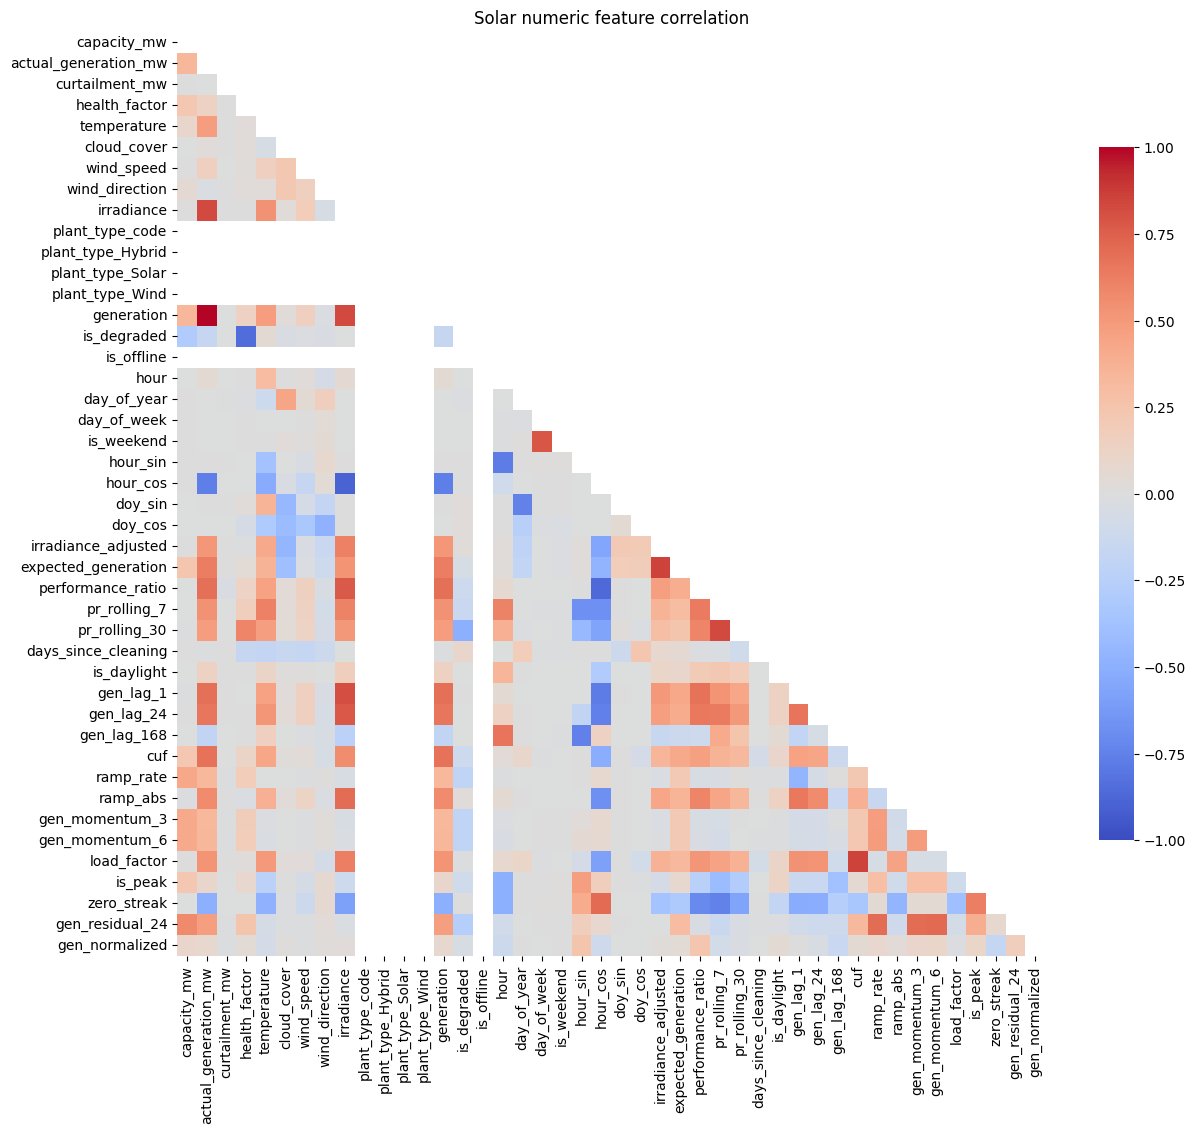


Processing Wind dataframe
Dropping 19 correlated features: ['net_availability_mw', 'health_adjusted_capacity_mw', 'generation_norm', 'month', 'month_sin', 'month_cos', 'wind_speed_squared', 'wind_speed_cubed', 'wind_power_density', 'turbine_efficiency', 'expected_wind_generation', 'air_density_adjusted', 'adjusted_wpd', 'gen_rolling_mean_24', 'gen_rolling_mean_168', 'cuf', 'daily_generation', 'gen_residual_24', 'gen_normalized']
Wind: 69 -> 50 columns after dropping correlated features


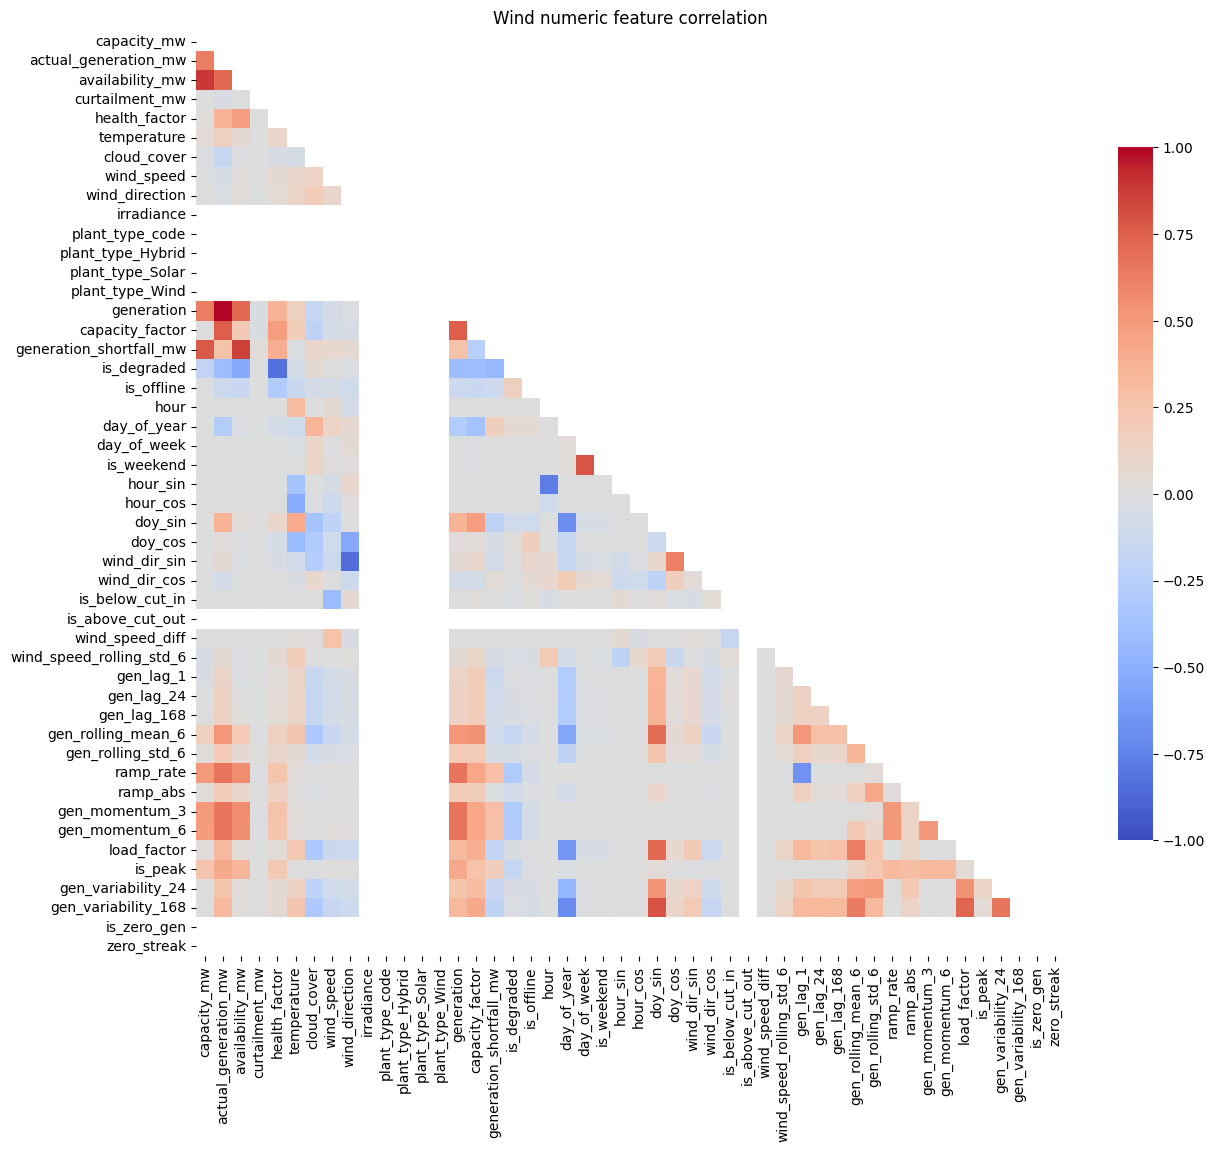


Processing Hybrid dataframe
Dropping 33 correlated features: ['availability_mw', 'health_factor', 'capacity_factor', 'net_availability_mw', 'health_adjusted_capacity_mw', 'generation_norm', 'month', 'doy_cos', 'month_sin', 'month_cos', 'clear_sky_irradiance', 'irradiance_ratio', 'temp_effect', 'expected_generation', 'pr_rolling_30', 'days_since_cleaning', 'soiling_loss', 'adjusted_generation_signal', 'wind_speed_squared', 'wind_speed_cubed', 'wind_power_density', 'turbine_efficiency', 'expected_wind_generation', 'air_density_adjusted', 'adjusted_wpd', 'gen_rolling_mean_6', 'gen_rolling_std_6', 'gen_rolling_mean_24', 'cuf', 'daily_generation', 'load_factor', 'gen_variability_24', 'gen_normalized']
Hybrid: 81 -> 48 columns after dropping correlated features


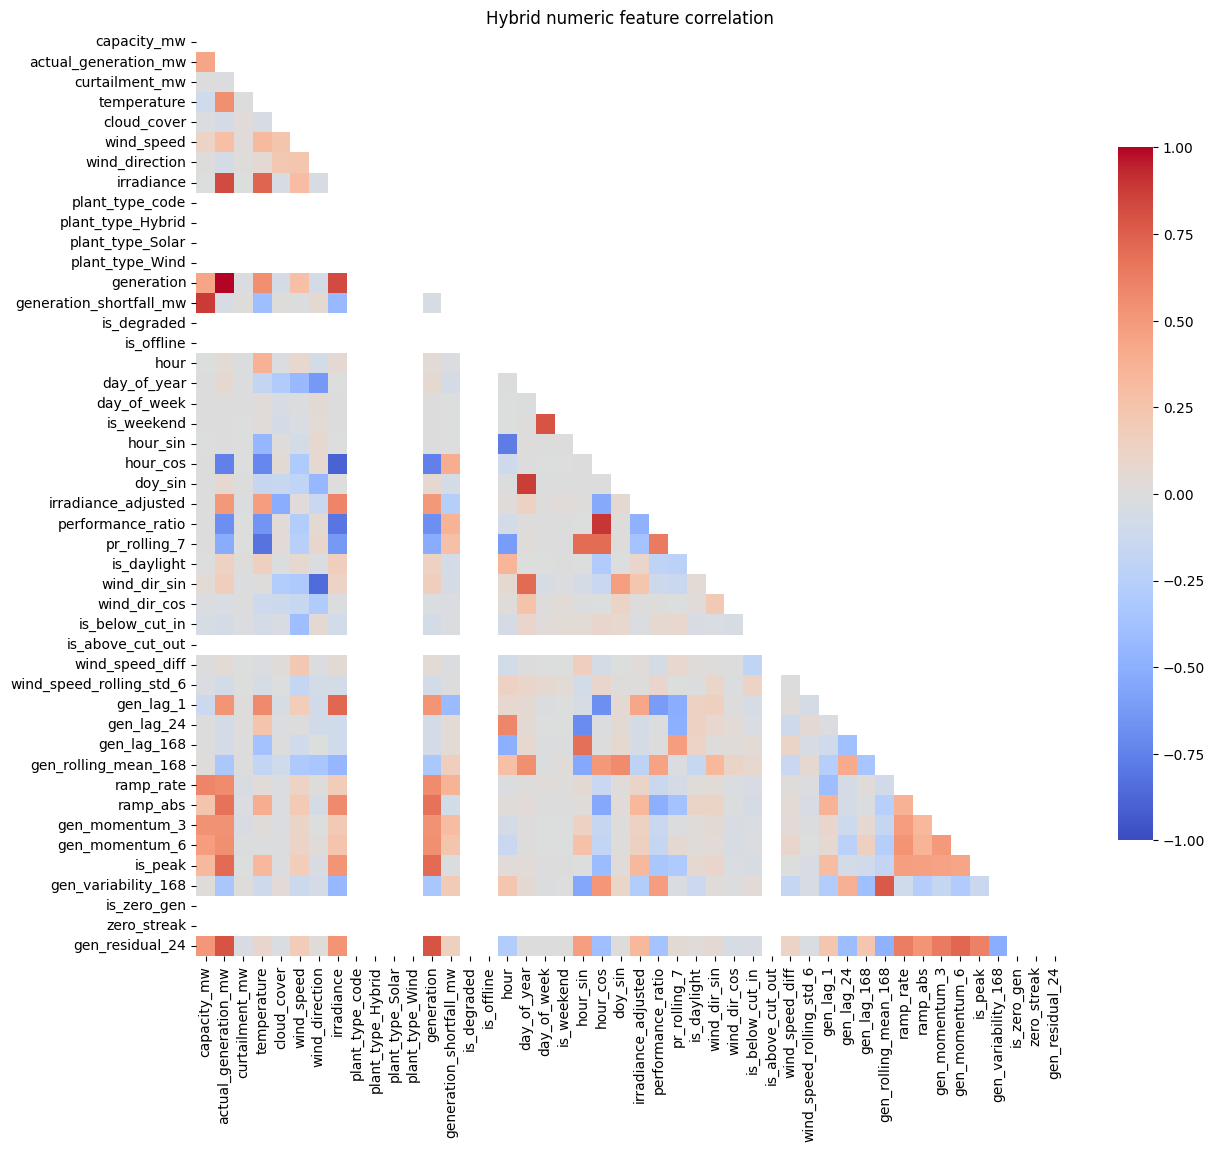

In [10]:
import seaborn as sns

import matplotlib.pyplot as plt

for label, df in [("Solar", df_solar), ("Wind", df_wind), ("Hybrid", df_hybrid)]:
    print(f"\nProcessing {label} dataframe")
    reduced_df = drop_correlated_features(df, threshold=0.90, exclude=["timestamp", "plant_id", "plant_type", "generation"])
    print(f"{label}: {df.shape[1]} -> {reduced_df.shape[1]} columns after dropping correlated features")
    globals()[f"df_{label.lower()}"] = reduced_df

    corr = reduced_df.select_dtypes("number").corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(14, 12))
    sns.heatmap(corr, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, center=0,
                cbar_kws={"shrink": 0.75}, annot=False)
    plt.title(f"{label} numeric feature correlation")
    plt.show()

### Step 2 — VIF check (surviving collinearity that correlation misses — e.g. one feature being a linear combination of three others)

In [11]:
!pip install statsmodels --quiet


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def drop_high_vif(df, threshold=10, exclude=["timestamp","plant_id","plant_type","generation"]):
    features = df.drop(columns=exclude, errors="ignore").select_dtypes("number").dropna()
    
    while True:
        vif = pd.DataFrame({
            "feature": features.columns,
            "VIF": [variance_inflation_factor(features.values, i) 
                    for i in range(features.shape[1])]
        }).sort_values("VIF", ascending=False)
        
        worst = vif.iloc[0]
        if worst["VIF"] < threshold:
            break
        print(f"Dropping {worst['feature']} (VIF={worst['VIF']:.1f})")
        features = features.drop(columns=[worst["feature"]])
    
    surviving = features.columns.tolist()
    return df[surviving + exclude]

In [ ]:
# Apply VIF filtering to all three dataframes
for plant_type, df in [("Solar", df_solar), ("Wind", df_wind), ("Hybrid", df_hybrid)]:
    print(f"\n{'='*60}")
    print(f"VIF Analysis for {plant_type}")
    print(f"{'='*60}")
    filtered_df = drop_high_vif(df, threshold=10, exclude=["timestamp", "plant_id", "generation"])
    globals()[f"df_{plant_type.lower()}"] = filtered_df
    print(f"{plant_type}: {df.shape[1]} -> {filtered_df.shape[1]} columns after VIF filtering\n")

# Bar plot showing surviving features count
import matplotlib.pyplot as plt

feature_counts = {
    "Solar": df_solar.shape[1],
    "Wind": df_wind.shape[1],
    "Hybrid": df_hybrid.shape[1]
}

plt.figure(figsize=(10, 6))
plt.bar(feature_counts.keys(), feature_counts.values(), color=['gold', 'steelblue', 'green'], alpha=0.7, edgecolor='black')
plt.ylabel('Number of Features', fontsize=12)
plt.title('Features Remaining After VIF Filtering (threshold=10)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for plant_type, count in feature_counts.items():
    plt.text(plant_type, count + 0.5, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Display column names for each plant type
print("\n" + "="*60)
print("Surviving Features by Plant Type")
print("="*60)
for plant_type in ["solar", "wind", "hybrid"]:
    df = globals()[f"df_{plant_type}"]
    print(f"\n{plant_type.upper()} ({df.shape[1]} features):")
    print(df.columns.tolist())


VIF Analysis for Solar
Dropping gen_lag_1 (VIF=3002399751580330.5)
Dropping plant_type_Solar (VIF=351.3)
Dropping pr_rolling_30 (VIF=298.5)
Dropping health_factor (VIF=110.1)


## Scale (different units — MW vs ratios vs degrees vs W/m²)

In [ ]:
!pip install scikit-learn --quiet


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.preprocessing import StandardScaler

def scale_features(df, exclude=["timestamp","plant_id", "generation"]):
    feature_cols = [c for c in df.columns if c not in exclude]
    
    scaler = StandardScaler()
    df[feature_cols] = scaler.fit_transform(df[feature_cols])
    return df, scaler  # return scaler to use on inference data

In [ ]:
# Apply scaling to each dataframe
df_solar_scaled, scaler_solar = scale_features(df_solar)
df_wind_scaled, scaler_wind = scale_features(df_wind)
df_hybrid_scaled, scaler_hybrid = scale_features(df_hybrid)

# Univariate Forecast

produce 72-hour generation forecasts per plant so those values can feed into the multivariate pipeline as lagged features.

Models compared per plant:
  - SARIMA   (captures seasonality, no external regressors)
  - Prophet  (handles multiple seasonalities + holidays cleanly)
  - LSTM     (learns non-linear temporal patterns)

Output: best_model per plant + 72-hour forecast array

In [ ]:
!pip install prophet 
!pip install torch 


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from src.univariate import run_univariate_fleet 



In [ ]:
run_univariate_fleet(df_solar_scaled)


Plant: PLANT_001 —(5,490 rows, 35 features)
[PLANT_001] stationary=True | daily_acf=0.91 | zero_rate=75.0% | CV=2.00 → prophet
  SARIMA AIC=61486.7 | BIC=61523.2


00:00:49 - cmdstanpy - INFO - Chain [1] start processing
00:00:54 - cmdstanpy - INFO - Chain [1] done processing


  Prophet fitted — 168h forecast range: [0.0, 26.1] MW
  LSTM epoch 10/50 loss=0.03778
  LSTM epoch 20/50 loss=0.03733
  LSTM epoch 30/50 loss=0.03712
  LSTM epoch 40/50 loss=0.03579
  LSTM epoch 50/50 loss=0.03827

  Winner for PLANT_001: SARIMA
    sarima  : MAE=2.178  RMSE=4.067  MAPE=22.1% <--
    prophet : MAE=7.302  RMSE=12.013  MAPE=61.6%
    lstm    : MAE=3.168  RMSE=5.706  MAPE=34.0%

  Refitting sarima on full series for 72h forecast...
  SARIMA AIC=62444.4 | BIC=62480.9

  [ERROR] PLANT_001: 'forecast_df'

Plant: PLANT_004 —(5,513 rows, 35 features)
[PLANT_004] stationary=True | daily_acf=0.92 | zero_rate=74.9% | CV=1.93 → prophet
  SARIMA AIC=60009.9 | BIC=60046.3


00:13:34 - cmdstanpy - INFO - Chain [1] start processing
00:13:40 - cmdstanpy - INFO - Chain [1] done processing


  Prophet fitted — 168h forecast range: [0.0, 28.4] MW


KeyboardInterrupt: 